In [50]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

EDA and Data Cleaning:
-

In [53]:
df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [55]:
df.shape

(140700, 20)

The dataset includes 140700 samples and 20 features.

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [60]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [62]:
df["Depression"].value_counts()

Depression
0    115133
1     25567
Name: count, dtype: int64

In [64]:
df["Depression"].value_counts(normalize=True)

Depression
0    0.818287
1    0.181713
Name: proportion, dtype: float64

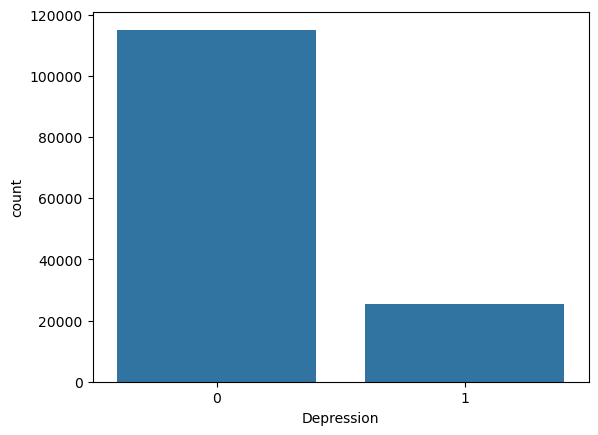

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df,x="Depression")
plt.show()

The classes are imbalanced; therefore, accuracy alone is not sufficient.

In [69]:
#Missing Values:
missing = df.isnull().sum()

missing[missing>0].sort_values(ascending=False)

Academic Pressure     112803
Study Satisfaction    112803
CGPA                  112802
Profession             36630
Work Pressure          27918
Job Satisfaction       27910
Dietary Habits             4
Financial Stress           4
Degree                     2
dtype: int64

Students usually do not have work pressure and Professionals usually do not have CGPA.

#Numerical analysis:
-

In [74]:
numerical_cols = [
'Age',
'Academic Pressure',
'Work Pressure',
'CGPA',
'Study Satisfaction',
'Job Satisfaction',
'Financial Stress'
]

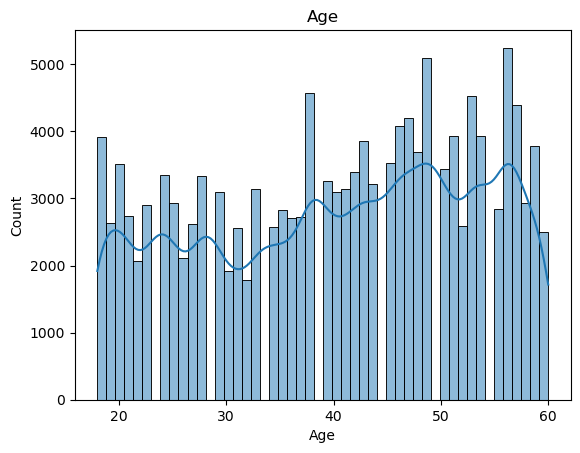

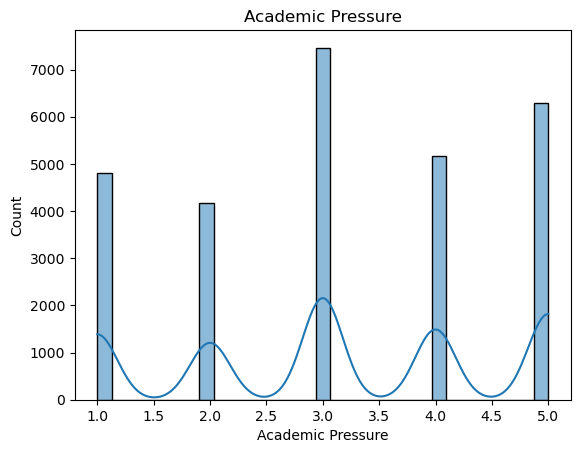

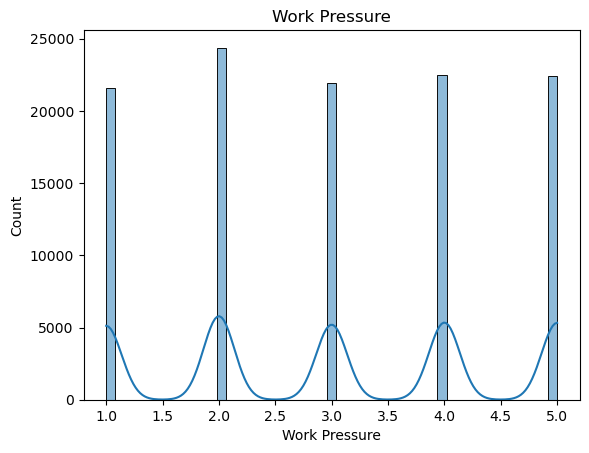

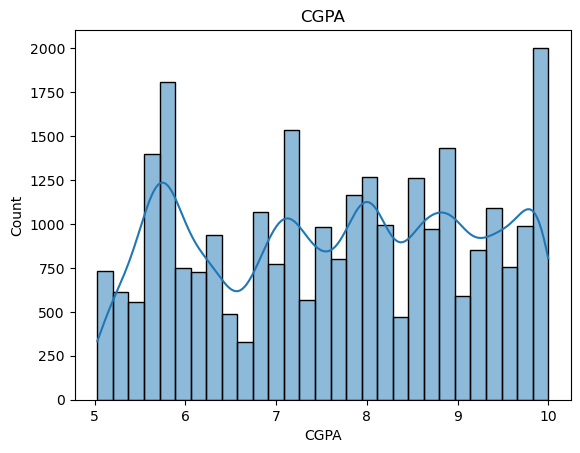

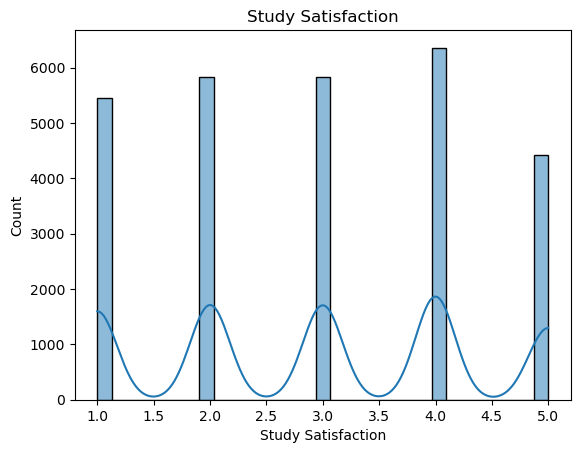

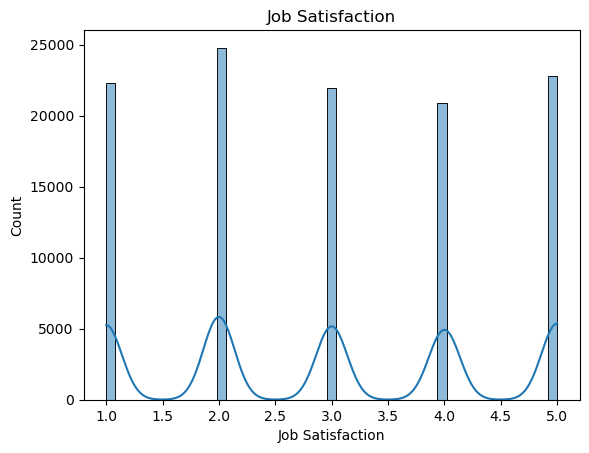

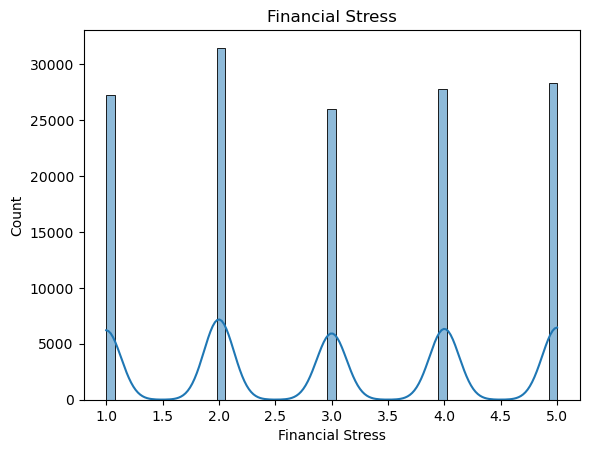

In [76]:
for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

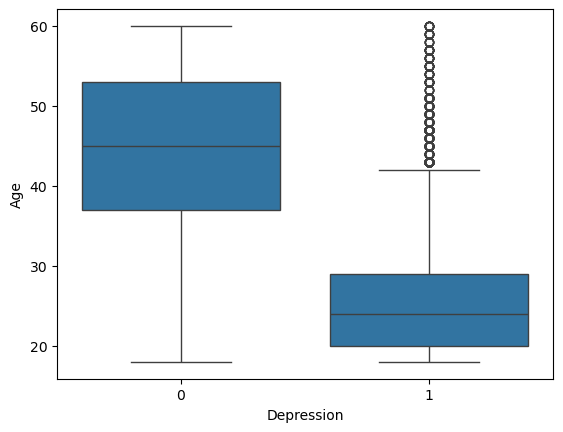

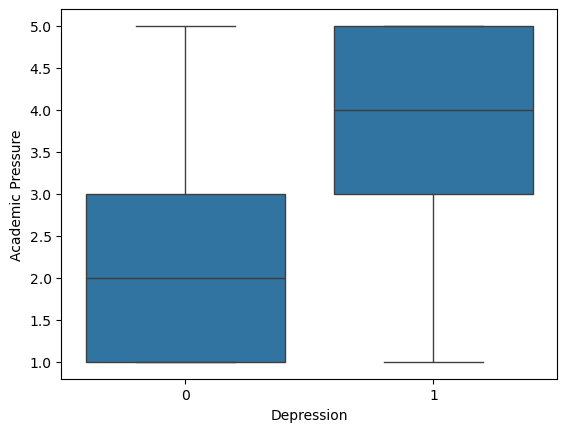

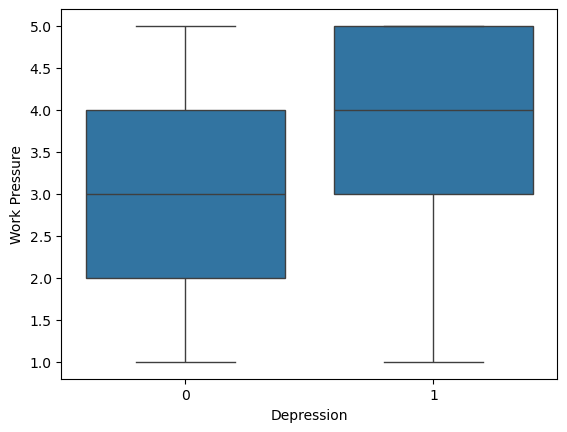

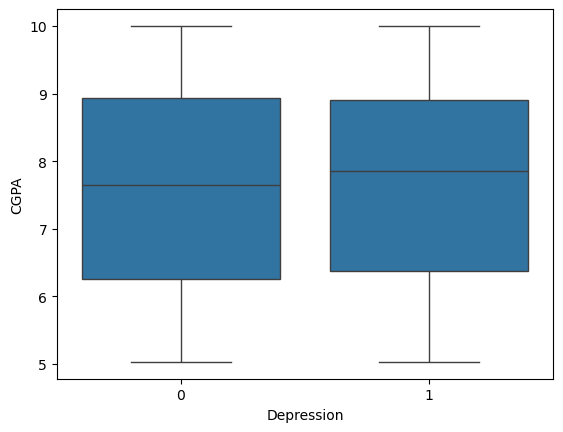

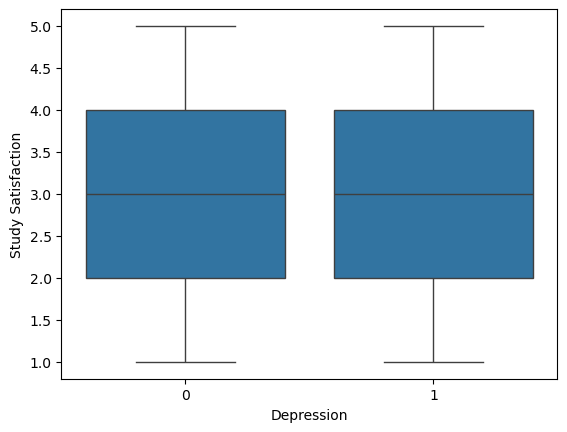

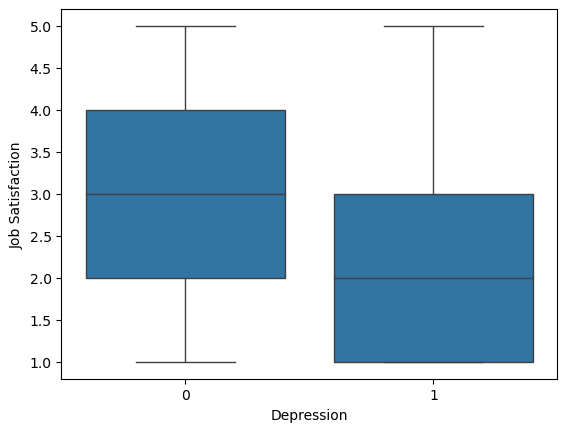

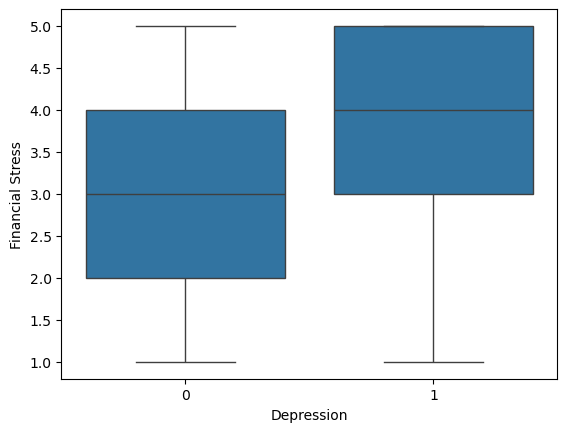

In [78]:
for col in numerical_cols:
    sns.boxplot(
        data=df,
        x='Depression',
        y=col
    )
    plt.show()

#Categorical Feature Analysis:
-

In [82]:
categorical_cols = df.select_dtypes(include=["object"]).columns

In [84]:
categorical_cols

Index(['Name', 'Gender', 'City', 'Working Professional or Student',
       'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')

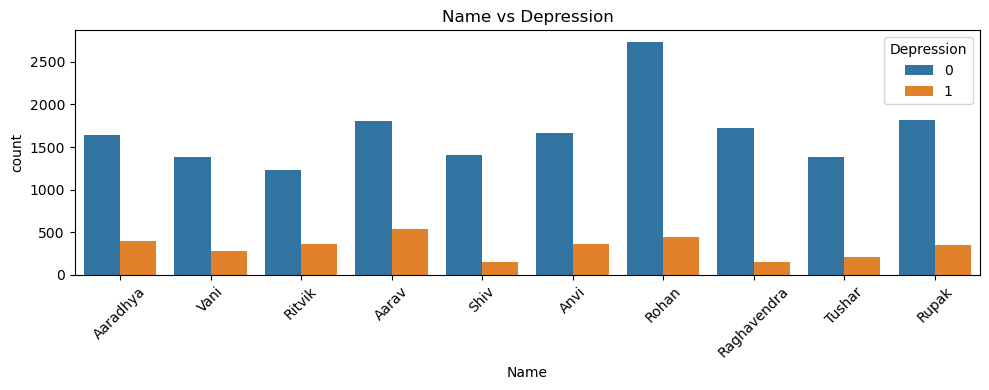

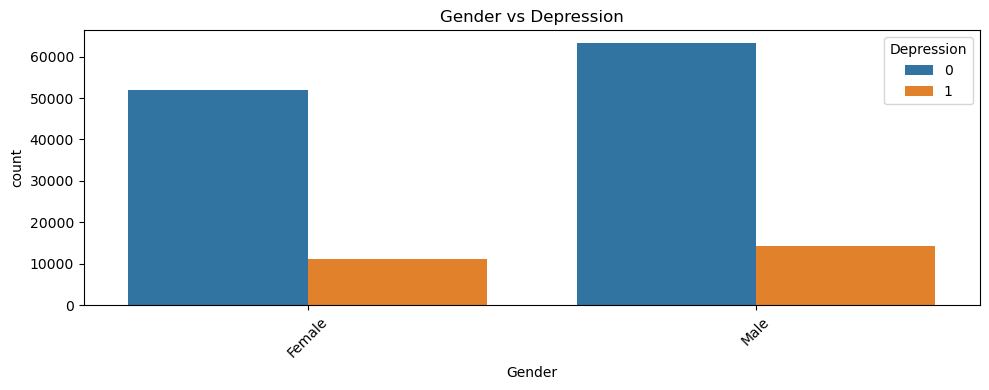

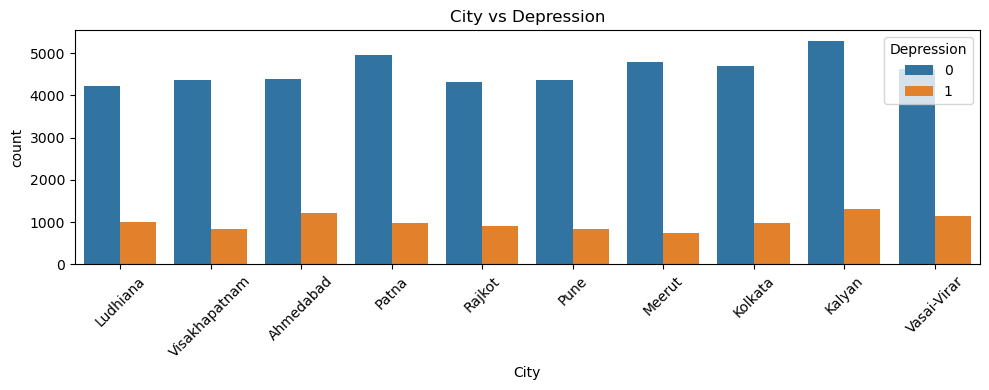

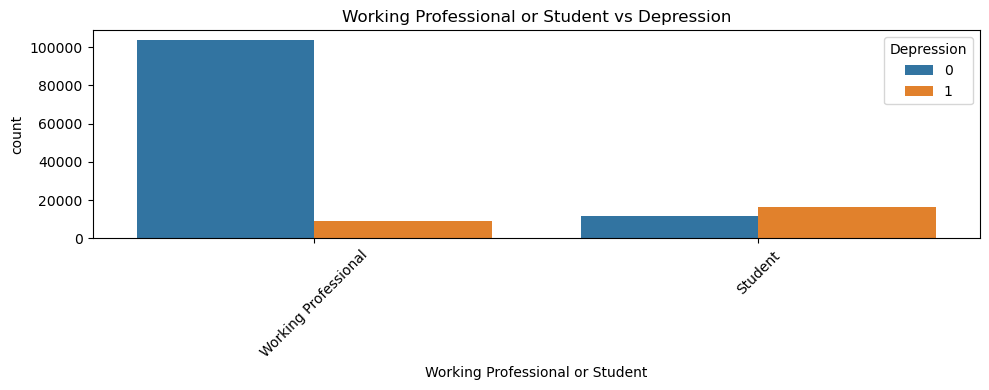

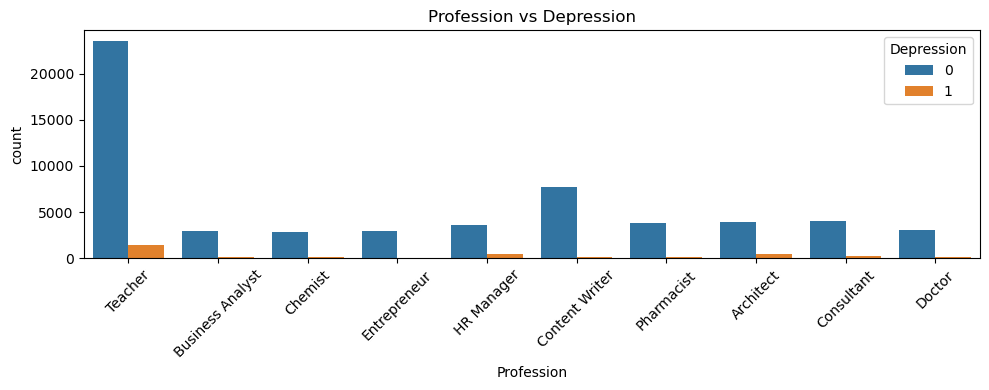

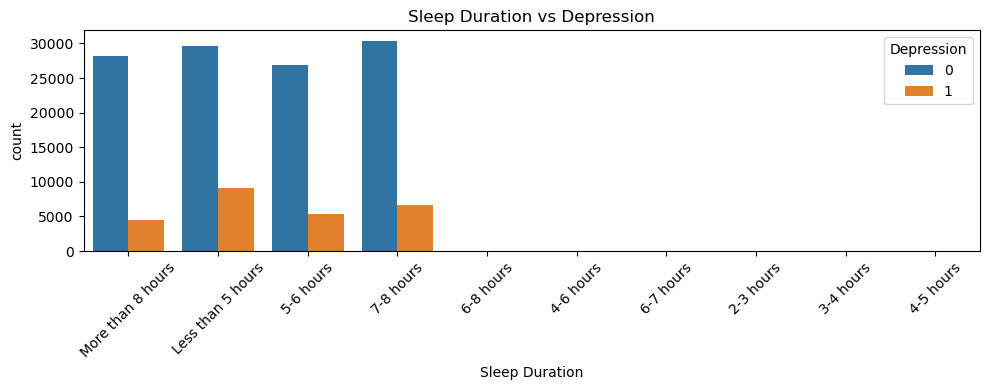

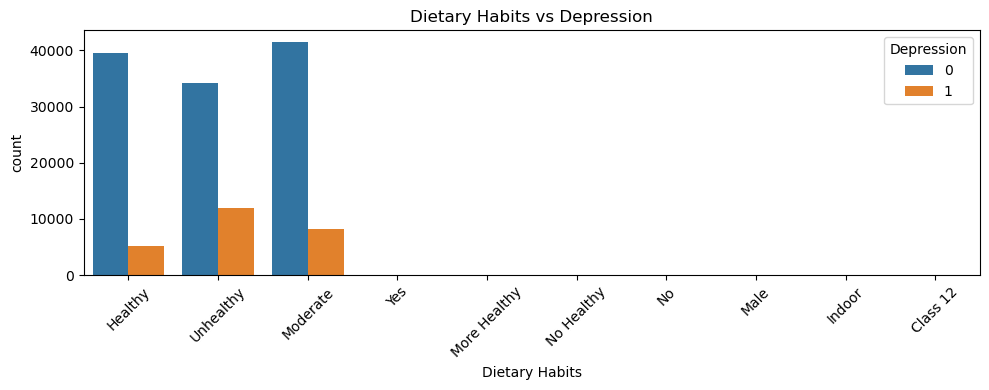

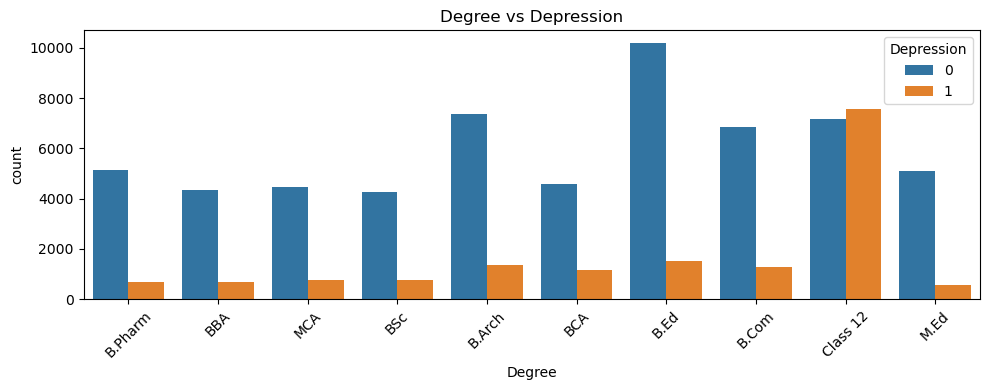

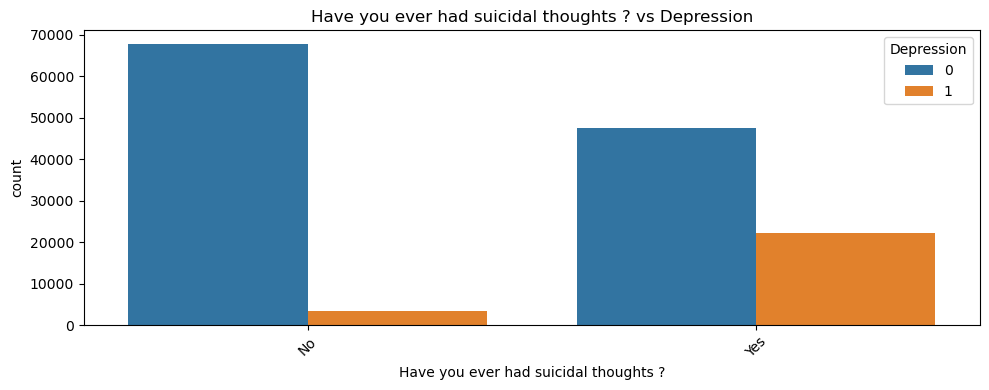

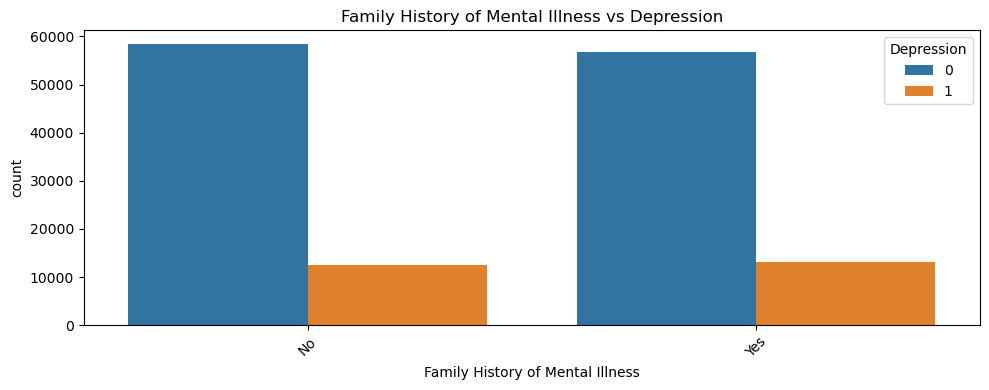

In [86]:
for col in categorical_cols:

    top_categories = df[col].value_counts().nlargest(10).index

    temp = df[df[col].isin(top_categories)]

    plt.figure(figsize=(10,4))

    sns.countplot(
        data=temp,
        x=col,
        hue="Depression"
    )

    plt.title(f"{col} vs Depression")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [87]:
for col in categorical_cols:

    print("\n")
    print("="*50)
    print(col)

    display(
        pd.crosstab(
            df[col],
            df["Depression"],
            normalize="index"
        ).round(3)
    )



Name


Depression,0,1
Name,,
18,0.000,1.000
A.Ed,1.000,0.000
Aadhya,0.808,0.192
Aahana,0.793,0.207
Aakash,0.783,0.217
...,...,...
Yuvraj,0.827,0.173
Zahra,1.000,0.000
Zara,0.909,0.091




Gender


Depression,0,1
Gender,,
Female,0.822,0.178
Male,0.815,0.185




City


...

Depression,0,1
Degree,,
0,0.0,1.0
20,0.0,1.0
24,0.0,1.0
29,1.0,0.0
5.56,1.0,0.0
...,...,...
Unite,0.0,1.0
Veda,1.0,0.0
Vivaan,1.0,0.0




Have you ever had suicidal thoughts ?


Depression,0,1
Have you ever had suicidal thoughts ?,,
No,0.951,0.049
Yes,0.682,0.318




Family History of Mental Illness


Depression,0,1
Family History of Mental Illness,,
No,0.825,0.175
Yes,0.812,0.188


### Summary of Categorical Feature Analysis

The exploratory analysis revealed that not all categorical variables contribute equally to depression risk. The strongest associations were observed for student status and suicidal thoughts, both of which showed substantial differences in depression prevalence across categories.

In contrast, gender and family history of mental illness exhibited relatively small differences between groups, suggesting weaker individual associations with depression.

These findings indicate that psychological and educational factors may play a more important role in depression prediction than demographic variables alone.

#Removing Unnecessary Columns:
-

In [93]:
df.columns.tolist()

['id',
 'Name',
 'Gender',
 'Age',
 'City',
 'Working Professional or Student',
 'Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Work/Study Hours',
 'Financial Stress',
 'Family History of Mental Illness',
 'Depression']

In [95]:
for col in df.columns:
    print(col, " --> ", df[col].nunique())

id  -->  140700
Name  -->  422
Gender  -->  2
Age  -->  43
City  -->  98
Working Professional or Student  -->  2
Profession  -->  64
Academic Pressure  -->  5
Work Pressure  -->  5
CGPA  -->  331
Study Satisfaction  -->  5
Job Satisfaction  -->  5
Sleep Duration  -->  36
Dietary Habits  -->  23
Degree  -->  115
Have you ever had suicidal thoughts ?  -->  2
Work/Study Hours  -->  13
Financial Stress  -->  5
Family History of Mental Illness  -->  2
Depression  -->  2


In [97]:
df = df.drop(
    columns=[
        "id",
        "Name"
    ]
)

In [99]:
df.shape

(140700, 18)

In [101]:
numerical_cols = [
    "Age",
    "Academic Pressure",
    "Work Pressure",
    "CGPA",
    "Study Satisfaction",
    "Job Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

In [103]:
categorical_cols = [
    "Gender",
    "City",
    "Working Professional or Student",
    "Profession",
    "Sleep Duration",
    "Dietary Habits",
    "Degree",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]

The `id` and `Name` variables were removed from the dataset before model training. The `id` variable serves only as a unique identifier and does not contain predictive information. Similarly, the `Name` variable uniquely identifies individuals and is not expected to have a meaningful relationship with depression status. Retaining such variables may introduce unnecessary noise and increase model complexity without improving predictive performance.

#Train/Test Split:
-

In [106]:
from sklearn.model_selection import train_test_split

X = df.drop("Depression", axis=1)

y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [108]:
#Pipeline:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Why median?

Because:

It is more resistant to outliers than the mean.  
It is more suitable for columns like Age or CGPA.

In [111]:
from sklearn.preprocessing import OneHotEncoder

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Why most_frequent?

For example, if Profession is empty:

The most frequent value will be used as a replacement.

Why handle_unknown="ignore"?

If we encounter a new category in the Test Set:

For instance, a city that was not in the Train set,

The model will not throw an error.

In [114]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipe, numerical_cols),
    ("cat", cat_pipe, categorical_cols)
])

The preprocessing steps were integrated within a scikit-learn Pipeline and ColumnTransformer so that all operations are fitted exclusively on the training data during cross-validation and model evaluation.

#Baseline Model:
-

In [118]:
from sklearn.dummy import DummyClassifier

dummy_model = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Academic Pressure',
                                                   'Work Pressure', 'CGPA',
                                                   'Study Satisfaction',
                                                   'Job Satisfaction',
                                                   'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'City',
                                                   'Working Professional or '
                                                   'Student',
                                                   'Profession',
                                                   'Sleep Duration',
                                                   'Dietary Habits', 'Degree',
                                                   'Have you ever had suicidal '
                                                   'thoughts ?',
                                                   'Family History of Mental '
                                                   'Illness'])])),
                ('model', DummyClassifier(strategy='most_frequent'))])

In [120]:
y_pred_dummy = dummy_model.predict(X_test)

In [122]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_dummy,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     23027
           1       0.00      0.00      0.00      5113

    accuracy                           0.82     28140
   macro avg       0.41      0.50      0.45     28140
weighted avg       0.67      0.82      0.74     28140



### Baseline Model Results

The DummyClassifier achieved an overall accuracy of approximately 82%, which initially appears reasonable. However, a closer examination of the classification metrics reveals that the model completely failed to identify any individuals with depression.

The recall, precision, and F1-score for the positive class were all equal to zero, indicating that the model predicted every observation as belonging to the majority class (non-depressed).

This result highlights the limitations of accuracy as a performance metric in imbalanced classification problems. Although the model achieved high accuracy, it provides no practical value as a depression screening tool because it fails to detect any positive cases.

Therefore, subsequent models will be evaluated using additional metrics such as Recall, Precision, F1-score, and ROC-AUC, with particular emphasis on identifying depressed individuals.

#Logistic Regression:
-

In [128]:
from sklearn.linear_model import LogisticRegression

In [130]:
log_model = Pipeline([
    ("prep",preprocessor),
    ("model",
     LogisticRegression(
         class_weight="balanced",
         max_iter=1000
     ))
])

In [132]:
log_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Academic Pressure',
                                                   'Work Pressure', 'CGPA',
                                                   'Study Satisfaction',
                                                   'Job Satisfaction',
                                                   'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'City',
                                                   'Working Professional or '
                                                   'Student',
                                                   'Profession',
                                                   'Sleep Duration',
                                                   'Dietary Habits', 'Degree',
                                                   'Have you ever had suicidal '
                                                   'thoughts ?',
                                                   'Family History of Mental '
                                                   'Illness'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [155]:
y_pred_log = log_model.predict(X_test)

In [157]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.98      0.91      0.95     23027
           1       0.70      0.92      0.80      5113

    accuracy                           0.91     28140
   macro avg       0.84      0.92      0.87     28140
weighted avg       0.93      0.91      0.92     28140



In [159]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_log))

[[21019  2008]
 [  385  4728]]


In [161]:
from sklearn.metrics import roc_auc_score

y_prob_log = log_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_prob_log
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9729884010769048


### Logistic Regression Results

Logistic Regression substantially outperformed the baseline classifier across all evaluation metrics. The model achieved an overall accuracy of approximately 91%, indicating strong predictive performance on the test set.

Most importantly, the model achieved a recall of 92% for the depression class, meaning that the vast majority of depressed individuals were successfully identified. This result is particularly important because failing to detect depression may have serious clinical consequences.

The confusion matrix showed only 385 false negatives, suggesting that relatively few depressed individuals were missed. Although the model generated 2,008 false positives, such errors may be more acceptable in a screening context than missed positive cases.

Furthermore, the model achieved a ROC-AUC score of 0.973, indicating excellent discrimination between depressed and non-depressed individuals. Overall, Logistic Regression provides a strong balance between predictive accuracy and sensitivity for depression detection.


#Random Forest:
-

In [135]:
from sklearn.ensemble import RandomForestClassifier

In [163]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model",
     RandomForestClassifier(
         n_estimators=200,
         max_depth=10,
         min_samples_leaf=5,
         random_state=42,
         n_jobs=-1
     ))
])

In [165]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [167]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     23027
           1       0.84      0.62      0.72      5113

    accuracy                           0.91     28140
   macro avg       0.88      0.80      0.83     28140
weighted avg       0.91      0.91      0.90     28140



In [169]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[22407   620]
 [ 1919  3194]]


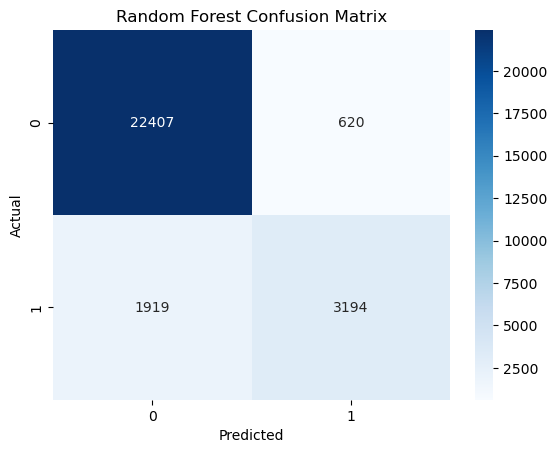

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [173]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [177]:
roc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("ROC-AUC:", roc_rf)

ROC-AUC: 0.9599152861404692


In [179]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.909772565742715
Precision: 0.8374410068169901
Recall   : 0.6246821826716213
F1 Score : 0.7155819424218662
ROC-AUC  : 0.9599152861404692


### Random Forest Results

The Random Forest classifier achieved an overall accuracy of approximately 91% and a ROC-AUC score of 0.96, indicating strong discriminative ability.

Compared with Logistic Regression, the model achieved higher precision (0.84), suggesting that positive predictions were more likely to be correct. However, recall for the depression class decreased substantially to approximately 62.5%.

This reduction in recall indicates that a larger number of depressed individuals were missed by the model. In a mental-health screening context, such false negatives may be particularly undesirable because individuals requiring support may remain unidentified.

Although Random Forest demonstrated competitive overall performance, Logistic Regression provided substantially higher sensitivity for detecting depression and may therefore be preferable for screening purposes.


#Threshold Tuning for Logistic Regression:
-

In [193]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.3,0.4,0.5,0.6,0.7]

for t in thresholds:

    pred = (y_prob_log >= t).astype(int)

    print(f"\nThreshold = {t}")

    print(
        "Precision:",
        round(
            precision_score(y_test,pred),
            3
        )
    )

    print(
        "Recall:",
        round(
            recall_score(y_test,pred),
            3
        )
    )

    print(
        "F1:",
        round(
            f1_score(y_test,pred),
            3
        )
    )


Threshold = 0.3
Precision: 0.61
Recall: 0.957
F1: 0.745

Threshold = 0.4
Precision: 0.658
Recall: 0.94
F1: 0.774

Threshold = 0.5
Precision: 0.702
Recall: 0.925
F1: 0.798

Threshold = 0.6
Precision: 0.743
Recall: 0.898
F1: 0.813

Threshold = 0.7
Precision: 0.786
Recall: 0.869
F1: 0.825


### Threshold Tuning

Logistic Regression produces probability estimates for each observation. By default, observations with predicted probabilities greater than 0.5 are classified as positive.

To investigate the trade-off between precision and recall, multiple classification thresholds were evaluated. Lower thresholds increased recall by identifying more potentially depressed individuals, whereas higher thresholds increased precision at the cost of missing more positive cases.

Given the screening nature of the problem, higher recall may be preferred because failing to identify a depressed individual is generally more costly than generating additional false positives.


#XGBoost:
-

In [45]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 1.9 MB/s eta 0:00:54
    --------------------------------------- 2.4/101.7 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 3.7/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 5.0/101.7 MB 4.8 MB/s eta 0:00:21
   -- ------------------------------------- 6.6/101.7 MB 5.0 MB/s eta 0:00:20
   --- ------------------------------------ 7.9/101.7 MB 5.2 MB/s eta 0:00:19
   --- ------------------------------------ 9.7/101.7 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 10.2/101.7 MB 5.7 MB/s eta 0:00:17
   ---- ------------

In [195]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("prep", preprocessor),
    ("model",
     XGBClassifier(
         n_estimators=300,
         max_depth=6,
         learning_rate=0.05,
         subsample=0.8,
         colsample_bytree=0.8,
         random_state=42,
         eval_metric="logloss"
     ))
])

In [197]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Academic Pressure',
                                                   'Work Pressure', 'CGPA',
                                                   'Study Satisfaction',
                                                   'Job Satisfaction',
                                                   'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [199]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [201]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23027
           1       0.84      0.81      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.90     28140
weighted avg       0.94      0.94      0.94     28140



In [203]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm_xgb)

[[22249   778]
 [  951  4162]]


In [205]:
roc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("ROC-AUC:", roc_xgb)

ROC-AUC: 0.9742111002933138


In [209]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.9385572139303483
Precision: 0.8425101214574898
Recall   : 0.814003520438099
F1 Score : 0.8280115388441261
ROC-AUC  : 0.9742111002933138


#Model Comparison and Final Model Selection
-

| Model                     |  Accuracy | Precision |    Recall |        F1 |   ROC-AUC |
| ------------------------- | --------: | --------: | --------: | --------: | --------: |
| Dummy                     |      0.82 |      0.00 |      0.00 |      0.00 |         - |
| Logistic Regression (0.5) |      0.91 |      0.70 | **0.925** |     0.798 |     0.973 |
| Logistic Regression (0.4) |         - |     0.658 | **0.940** |     0.774 |     0.973 |
| Random Forest             |     0.910 | **0.837** |     0.625 |     0.716 |     0.960 |
| XGBoost                   | **0.939** | **0.843** |     0.814 | **0.828** | **0.974** |


### Final Model Selection

Three machine-learning models were evaluated for depression prediction: Logistic Regression, Random Forest, and XGBoost.

Random Forest achieved competitive accuracy but demonstrated substantially lower recall for the depression class, making it less suitable for a screening application where missed positive cases are costly.

Logistic Regression achieved the highest recall, successfully identifying more than 92% of depressed individuals. This characteristic is particularly valuable in mental-health screening because false negatives may prevent individuals from receiving timely support.

XGBoost achieved the best overall predictive performance, obtaining the highest accuracy (93.9%), F1-score (0.828), and ROC-AUC (0.974). However, its recall was lower than that of Logistic Regression.

Because the primary objective of the application is early identification of depression and the cost of false negatives is considered higher than the cost of false positives, Logistic Regression was selected as the preferred screening model. Nevertheless, XGBoost demonstrated the strongest overall predictive capability and may be preferred when a balanced trade-off between precision and recall is desired.


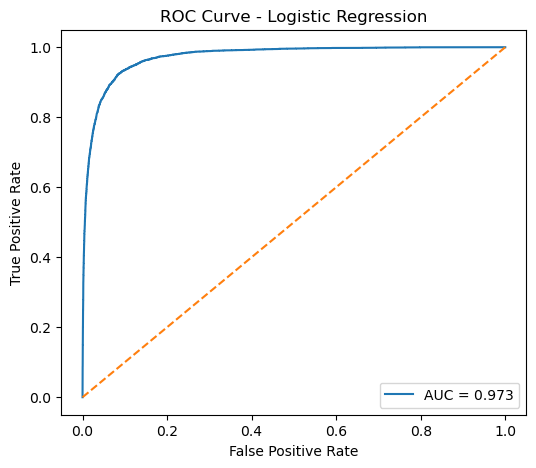

In [224]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_log = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

The model achieved a high ROC-AUC score (0.973), demonstrating strong overall discriminative ability. In addition, Logistic Regression is computationally efficient, interpretable, and relatively resistant to overfitting compared with more complex models.

In [228]:
feature_names = preprocessor.get_feature_names_out()

coef = log_model.named_steps["model"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

coef_df["AbsCoef"] = coef_df["Coefficient"].abs()

coef_df.sort_values(
    "AbsCoef",
    ascending=False
).head(15)

,Feature,Coefficient,AbsCoef
0,num__Age,-2.119435,2.119435
316,cat__Have you ever had suicidal thoughts ?_No,-1.502926,1.502926
95,cat__Working Professional or Student_Working P...,-1.211115,1.211115
118,cat__Profession_Entrepreneur,-1.020643,1.020643
317,cat__Have you ever had suicidal thoughts ?_Yes,0.922532,0.922532
110,cat__Profession_Content Writer,-0.814251,0.814251
140,cat__Profession_Pharmacist,-0.808686,0.808686
2,num__Work Pressure,0.782477,0.782477
7,num__Financial Stress,0.769528,0.769528
106,cat__Profession_Chemist,-0.746530,0.746530


The Logistic Regression model highlights age, suicidal thoughts, student status, work pressure, financial stress, dietary habits, and job satisfaction as some of the most influential predictors of depression within the dataset.